In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 기상 데이터 불러오기
weather_df = pd.read_csv('../../data/raw/gisang/gisang.csv', encoding='cp949')
#print(weather_df)

In [21]:
# 날짜 포맷을 datetime 타입으로 변환 
weather_df['date'] = pd.to_datetime(weather_df['일시'])

# 결측치(NaN) 처리 (비/눈이 안 온 날은 0mm, 0cm)
weather_df['일강수량(mm)'] = weather_df['일강수량(mm)'].fillna(0)
weather_df['일 최심적설(cm)'] = weather_df['일 최심적설(cm)'].fillna(0)
weather_df['1시간 최다강수량(mm)'] = weather_df['1시간 최다강수량(mm)'].fillna(0)

weather_df['평균기온(°C)'] = weather_df['평균기온(°C)'].interpolate(method='linear')
#print(weather_df)

In [22]:
# 분석에 사용할 핵심 변수들과 '지점명(지역)' 컬럼 유지
weather_clean = weather_df[['date', '지점명', '평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '일 최심적설(cm)']]

# 전처리 결과 확인 
print("포함된 경기도 지역 목록:", weather_clean['지점명'].unique())
print("\n결측치 처리 확인:")
print(weather_clean.isnull().sum())
print(weather_clean.head())

포함된 경기도 지역 목록: <ArrowStringArray>
['동두천', '파주', '수원', '양평', '이천']
Length: 5, dtype: str

결측치 처리 확인:
date          0
지점명           0
평균기온(°C)      0
일강수량(mm)      0
평균 풍속(m/s)    0
일 최심적설(cm)    0
dtype: int64
        date  지점명  평균기온(°C)  일강수량(mm)  평균 풍속(m/s)  일 최심적설(cm)
0 2022-01-01  동두천      -6.4       0.0         0.7         0.0
1 2022-01-02  동두천      -2.1       0.3         1.3         0.0
2 2022-01-03  동두천      -4.0       0.0         1.0         0.0
3 2022-01-04  동두천      -3.9       0.0         1.2         0.0
4 2022-01-05  동두천      -5.1       0.0         0.7         0.0


In [7]:
# 3개 지역만 추출
target_regions = ['동두천', '양평', '수원']
weather_filtered = weather_clean[weather_clean['지점명'].isin(target_regions)].copy()

# 지역명을 북부, 동부, 남부로 변경
region_mapping = {
    '동두천': '북부',
    '양평': '동부',
    '수원': '남부'
}
weather_filtered['지점명'] = weather_filtered['지점명'].map(region_mapping)

In [11]:
# 기온 및 풍속 상하한선 제한 (상위 99.9% / 하위 0.1%)
for col in ['평균기온(°C)', '평균 풍속(m/s)']:
    lower = weather_filtered[col].quantile(0.001)
    upper = weather_filtered[col].quantile(0.999)
    weather_filtered[col] = weather_filtered[col].clip(lower=lower, upper=upper)

# 강수량 및 적설 상한선 제한 (상위 99.5%)
for col in ['일강수량(mm)', '일 최심적설(cm)']:
    upper_limit = weather_filtered[col].quantile(0.995)
    weather_filtered[col] = weather_filtered[col].clip(upper=upper_limit)

Text(0, 0.5, '풍속 (m/s)')

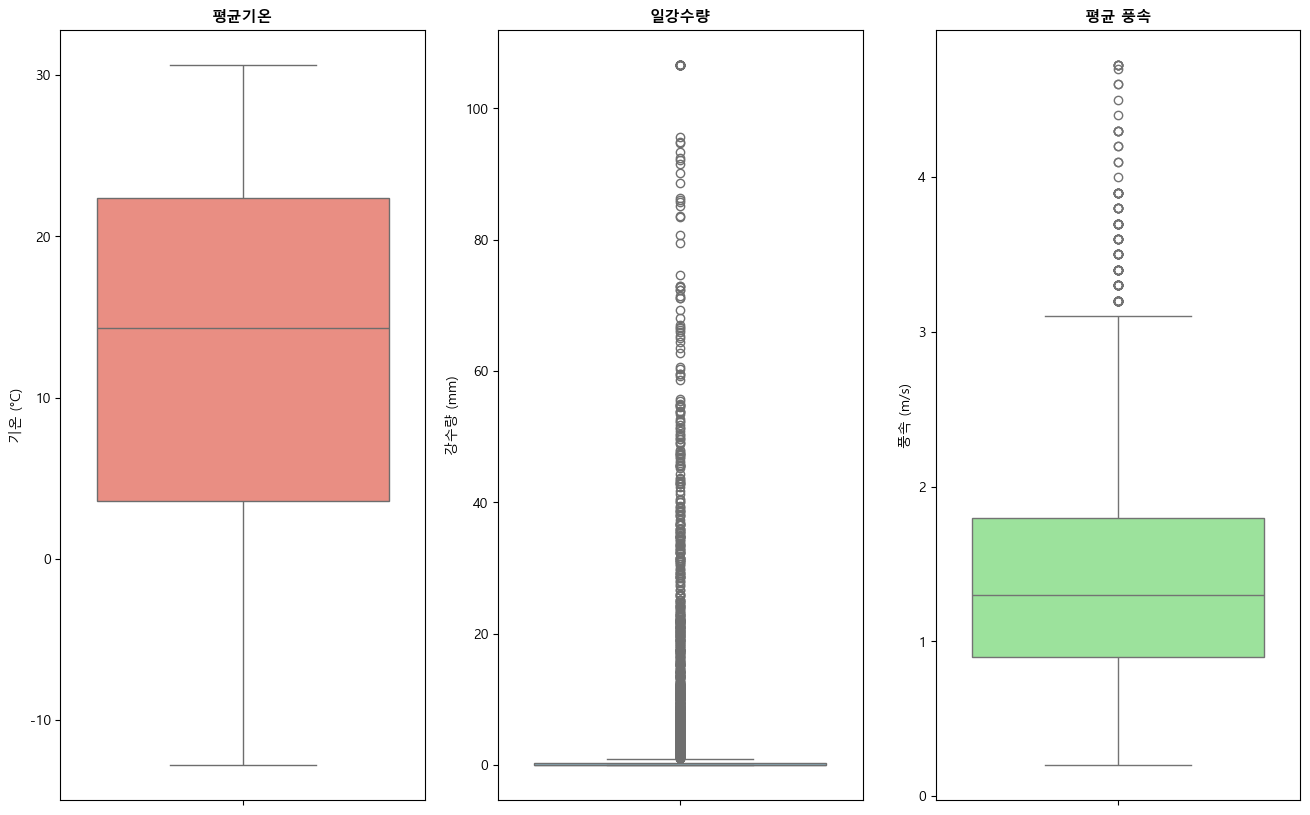

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 10))

sns.boxplot(data=weather_filtered, y='평균기온(°C)', ax=axes[0], color='salmon')
axes[0].set_title("평균기온", fontsize=11, fontweight='bold')
axes[0].set_ylabel("기온 (°C)")

sns.boxplot(data=weather_filtered, y='일강수량(mm)', ax=axes[1], color='skyblue')
axes[1].set_title("일강수량", fontsize=11, fontweight='bold')
axes[1].set_ylabel("강수량 (mm)")

sns.boxplot(data=weather_filtered, y='평균 풍속(m/s)', ax=axes[2], color='lightgreen')
axes[2].set_title("평균 풍속", fontsize=11, fontweight='bold')
axes[2].set_ylabel("풍속 (m/s)")

In [18]:
for region in ['북부', '동부', '남부']:
    # 해당 지역의 데이터만 필터링
    region_df = weather_clean[weather_clean['지점명'] == region].copy()
    
    # 'date' 컬럼을 데이터프레임의 고유한 Key로 지정
    region_df = region_df.set_index('date')
    
    # 파일명 생성
    file_name = f'weather_{region}.csv'
    
    # CSV 파일로 저장
    region_df.to_csv(file_name, index=True, encoding='utf-8-sig')
    print(f"{file_name} 저장 완료! (Key: 날짜 데이터 / 행 수: {len(region_df)}개)")

weather_북부.csv 저장 완료! (Key: 날짜 데이터 / 행 수: 0개)
weather_동부.csv 저장 완료! (Key: 날짜 데이터 / 행 수: 0개)
weather_남부.csv 저장 완료! (Key: 날짜 데이터 / 행 수: 0개)
